# ai_videogames · Reto evaluable PRO
## Transfer Learning para criaturas RPG

### Objetivo
Construir un clasificador de criaturas inspirado en RPG usando **Oxford-IIIT Pet** y una arquitectura preentrenada.

### Metas orientativas
- **Accuracy ≥ 0.80** en fase 1
- **Accuracy ≥ 0.85** tras fine-tuning

> No son obligatorias si tu análisis es bueno, pero sirven como referencia.


In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

IMG_SIZE = 160
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

(ds_train_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=["train[:80%]", "train[80%:]"],
    with_info=True,
    as_supervised=True
)

label_names = ds_info.features["label"].names
num_classes = ds_info.features["label"].num_classes
print("Clases:", num_classes)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.FYNSMK_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.FYNSMK_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.
Clases: 37


## 1) Preprocesado
Completa el pipeline de datos y documenta brevemente qué hace cada paso.


In [2]:
# TODO: elige preprocess_input según tu arquitectura
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = preprocess_input(tf.cast(image, tf.float32))
    return image, label

train_ds = (
    ds_train_raw
    .shuffle(2000, seed=SEED)
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    ds_test_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

## 2) Data augmentation
Añade al menos 2 transformaciones y justifícalas en una celda markdown.


In [3]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

## 3) Fase 1 · Feature extraction
Usa una base preentrenada y congélala.
Sugerencias:
- MobileNetV2
- EfficientNetB0
- ResNet50


In [9]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=2,
        restore_best_weights=True
    )
]

history_1 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 87ms/step - accuracy: 0.5649 - loss: 1.5884 - val_accuracy: 0.8139 - val_loss: 0.6593
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8393 - loss: 0.5462 - val_accuracy: 0.8505 - val_loss: 0.4916
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 76ms/step - accuracy: 0.8835 - loss: 0.3850 - val_accuracy: 0.8668 - val_loss: 0.4275
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 69ms/step - accuracy: 0.9079 - loss: 0.3114 - val_accuracy: 0.8655 - val_loss: 0.4282
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 73ms/step - accuracy: 0.9287 - loss: 0.2562 - val_accuracy: 0.8682 - val_loss: 0.4006


In [10]:
#Se comprueba la precisión del modelo antes del Fine-Tuning
loss, acc = model.evaluate(test_ds, verbose=0)
print("Accuracy final:", acc)

Accuracy final: 0.8682065010070801


## 4) Fase 2 · Fine-tuning
Desbloquea parcialmente la base y vuelve a entrenar con learning rate más bajo.


In [11]:
base_model.trainable = True

# TODO: puedes experimentar con este corte
fine_tune_at = 200
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    initial_epoch=history_1.epoch[-1] + 1,
    callbacks=callbacks
)

Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 88ms/step - accuracy: 0.9419 - loss: 0.2237 - val_accuracy: 0.8764 - val_loss: 0.3948
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.9358 - loss: 0.2199 - val_accuracy: 0.8777 - val_loss: 0.3914
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 77ms/step - accuracy: 0.9453 - loss: 0.2065 - val_accuracy: 0.8791 - val_loss: 0.3886
Epoch 9/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 66ms/step - accuracy: 0.9416 - loss: 0.2157 - val_accuracy: 0.8804 - val_loss: 0.3855
Epoch 10/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - accuracy: 0.9521 - loss: 0.1995 - val_accuracy: 0.8818 - val_loss: 0.3831
Epoch 11/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.9440 - loss: 0.2042 - val_accuracy: 0.8804 - val_loss: 0.3823
Epoch 12/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 20s 76ms/step - accuracy: 0.9443 - loss: 0.2061 - val_accuracy: 0.8818 - val_loss: 0.3812


In [12]:
loss, acc = model.evaluate(test_ds, verbose=0)
print("Accuracy final:", acc)

Accuracy final: 0.8817934989929199


## 5) Curvas de entrenamiento
Representa:
- accuracy train
- accuracy validación
- marca el punto donde empieza el fine-tuning


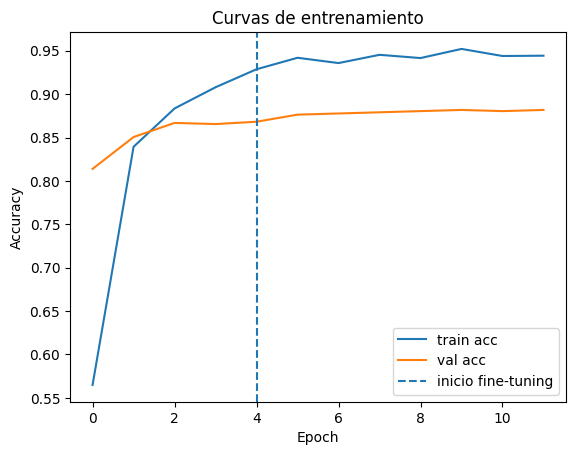

In [13]:
acc = history_1.history["accuracy"] + history_2.history["accuracy"]
val_acc = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]

plt.figure()
plt.plot(acc, label="train acc")
plt.plot(val_acc, label="val acc")
plt.axvline(x=len(history_1.history["accuracy"])-1, linestyle="--", label="inicio fine-tuning")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Curvas de entrenamiento")
plt.show()

## 6) Evaluación cuantitativa
Reporta accuracy final y compárala con tus objetivos.


In [14]:
loss, acc = model.evaluate(test_ds, verbose=0)
print("Accuracy final:", acc)

Accuracy final: 0.8817934989929199


## 7) Evaluación cualitativa
Muestra:
- 12 ejemplos correctamente clasificados
- 12 errores
- análisis breve de qué tipo de confusiones observas


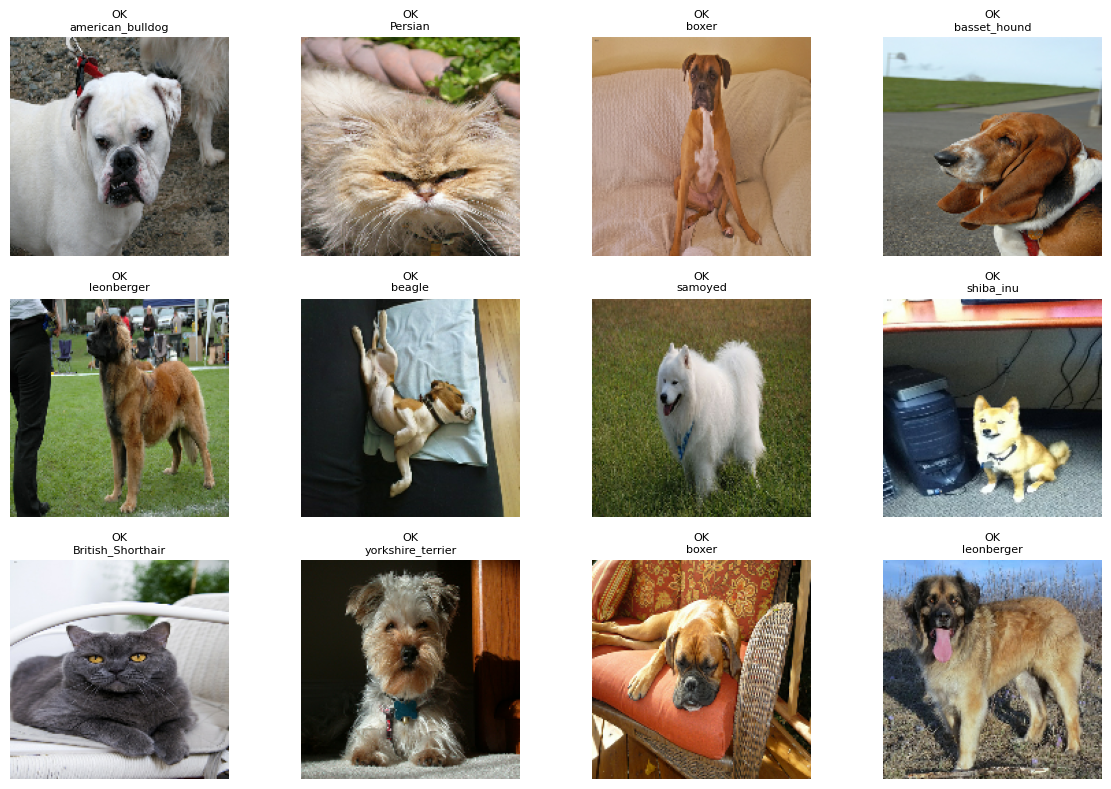

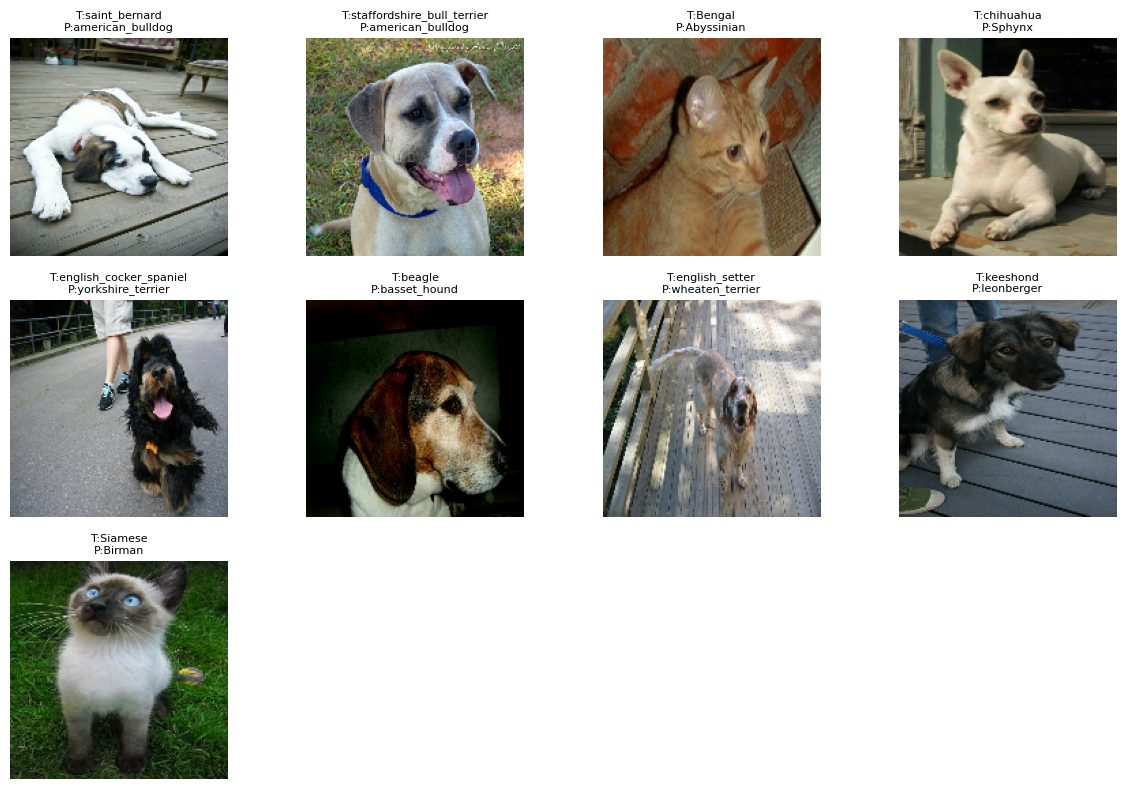

In [15]:
sample_images = []
sample_labels = []

for images, labels in test_ds.take(3):
    sample_images.append(images)
    sample_labels.append(labels)

sample_images = tf.concat(sample_images, axis=0)
sample_labels = tf.concat(sample_labels, axis=0)

preds = model.predict(sample_images, verbose=0)
pred_classes = np.argmax(preds, axis=1)

correct = np.where(pred_classes == sample_labels.numpy())[0]
wrong = np.where(pred_classes != sample_labels.numpy())[0]

plt.figure(figsize=(12,8))
for i, idx in enumerate(correct[:12]):
    plt.subplot(3,4,i+1)
    img = (sample_images[idx].numpy() + 1.0) / 2.0
    plt.imshow(np.clip(img,0,1))
    plt.title(f"OK\n{label_names[int(pred_classes[idx])]}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,8))
for i, idx in enumerate(wrong[:12]):
    plt.subplot(3,4,i+1)
    img = (sample_images[idx].numpy() + 1.0) / 2.0
    plt.imshow(np.clip(img,0,1))
    t = label_names[int(sample_labels[idx])]
    p = label_names[int(pred_classes[idx])]
    plt.title(f"T:{t}\nP:{p}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

## 8) Matriz de confusión (bonus recomendable)


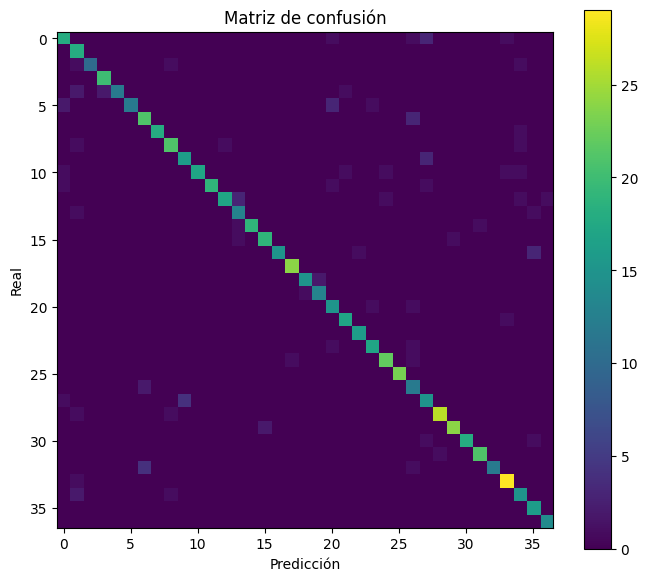

In [16]:
all_preds = []
all_true = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    all_preds.append(np.argmax(preds, axis=1))
    all_true.append(labels.numpy())

all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)

cm = tf.math.confusion_matrix(all_true, all_preds, num_classes=num_classes).numpy()

plt.figure(figsize=(8,7))
plt.imshow(cm)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.colorbar()
plt.show()

## 9) Guardar modelo
Usa un nombre que incluya tu equipo o usuario.


In [17]:
model.save("semana3_pro_Straixer_transfer_learning.keras")

## 10) Reflexión final (obligatoria)
Responde en 10–15 líneas:
- ¿Qué ventaja viste en usar transfer learning frente a entrenar desde cero?
El transfer learning hace que el desarrollar una IA sea menos costoso, ya que las primeras capas son más generalistas y no hace falta que cambien entre distintos usos de la IA.  
- ¿Qué diferencia observaste entre feature extraction y fine-tuning?
Que en feature extraction se congela todo el modelo descargado y se le añaden nuevas capas para que se entrenen y sirvan para el propósito que necesitamos. En la etapa de fine-tuning se descongelan algunas capas del modelo original para que se ajuste aún más, pero hay que tener cuidado con el número de capas que se descongelan ya que podría ser antiproducente si descongelas demasiadas.
- ¿Qué limitaciones tendría este modelo si lo aplicas a sprites, enemigos o criaturas de un videojuego real?
